In [24]:
import pandas as pd

from protest_impact.util import project_root

count_df = pd.read_csv(
    project_root / "data" / "protest" / "protest_and_topic_counts.csv"
)
count_df["date"] = pd.to_datetime(count_df["date"])
count_df.head()

,date,topic,count,type
0,2014-01-03,feminism,1,protest
1,2014-01-03,labour,1,protest
2,2014-01-03,racism,1,protest
3,2014-01-03,yellow jackets,1,protest
4,2014-01-04,anti-war,1,protest


In [25]:
topic_count_df = count_df.copy()[count_df["type"] == "general"]
topic_count_df["count"] = topic_count_df.groupby("date")["count"].transform(
    lambda x: x / x.sum()
)
topic_count_df.head()

,date,topic,count,type
14970,2010-01-09,feminism,1.0,general
14971,2010-02-08,covid,0.5,general
14972,2010-02-08,feminism,0.5,general
14973,2010-03-01,racism,1.0,general
14974,2010-03-09,feminism,0.5,general


In [58]:
from dateutil import relativedelta

data = []
zero_count = 0
for topic in count_df["topic"].unique():
    df = count_df[count_df["topic"] == topic]
    protest_counts = df[
        (df["type"] == "protest")
        & (df.date.dt.year >= 2014)
        & (df.date.dt.year <= 2021)
    ]
    for a in protest_counts.to_dict(orient="records"):
        one_month_ago = a["date"] - relativedelta.relativedelta(months=1)
        two_days_ago = a["date"] - relativedelta.relativedelta(days=2)
        previous_month_count = topic_count_df[
            (topic_count_df.date >= one_month_ago)
            & (topic_count_df.date <= two_days_ago)
            & (topic_count_df.topic == topic)
        ]["count"].sum()
        one_month_later = a["date"] + relativedelta.relativedelta(months=1)
        two_days_later = a["date"] + relativedelta.relativedelta(days=2)
        next_month_count = topic_count_df[
            (topic_count_df.date >= two_days_later)
            & (topic_count_df.date <= one_month_later)
            & (topic_count_df.topic == topic)
        ]["count"].sum()
        if previous_month_count == 0 or next_month_count == 0:
            zero_count += 1
            continue
        data.append(
            {
                "topic": topic,
                "date": a["date"],
                "protest_count": a["count"],
                "previous_month_count": previous_month_count,
                "next_month_count": next_month_count,
                "change": next_month_count / previous_month_count,
            }
        )

df = pd.DataFrame(data)
df.head()

,topic,date,protest_count,previous_month_count,next_month_count,change
0,feminism,2014-01-03,1,3.994200,3.849557,0.963787
1,feminism,2014-01-04,1,4.053734,3.858657,0.951877
2,feminism,2014-01-28,1,3.850001,3.909790,1.015530
3,feminism,2014-02-14,1,3.772345,3.923708,1.040124
4,feminism,2014-02-21,1,3.968164,4.100823,1.033431


In [59]:
zero_count, len(df)

(1523, 12435)

<AxesSubplot: >

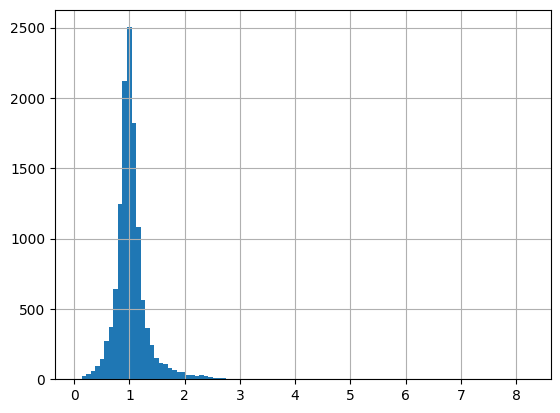

In [60]:
df["change"].hist(bins=100)

<AxesSubplot: >

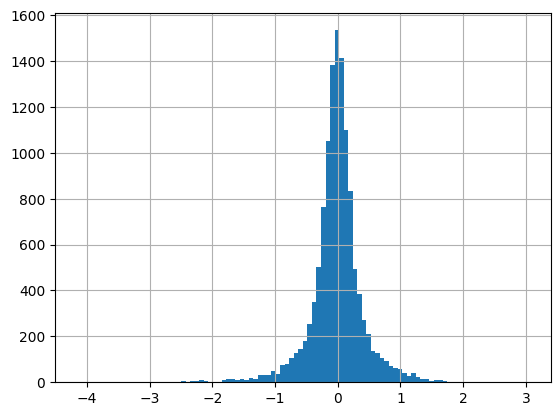

In [61]:
import numpy as np

df["log_change"] = df["change"].apply(lambda x: np.log2(x))
df["log_change"].hist(bins=100)

In [62]:
df["log_change"].describe()

count    12435.000000
mean        -0.015375
std          0.423034
min         -4.148383
25%         -0.179345
50%         -0.009643
75%          0.159285
max          3.039611
Name: log_change, dtype: float64

In [63]:
stats = []
for topic in df["topic"].unique():
    stats.append(
        {
            "topic": topic,
            "mean": df[df["topic"] == topic]["log_change"].mean(),
            "std": df[df["topic"] == topic]["log_change"].std(),
        }
    )
stats_df = pd.DataFrame(stats)
stats_df

,topic,mean,std
0,feminism,-0.002669,0.157619
1,labour,-0.006323,0.316812
2,racism,-0.008783,0.179594
3,yellow jackets,-0.018409,0.166933
4,anti-war,-0.014609,0.230292
5,right wing,-0.048770,0.812500
6,animal rights,0.008814,0.340740
7,climate,0.014695,0.314299
8,environment,-0.015598,0.259569
9,anti-immigration,-0.040227,0.219559


array([[<AxesSubplot: title={'center': 'mean'}>,
        <AxesSubplot: title={'center': 'std'}>]], dtype=object)

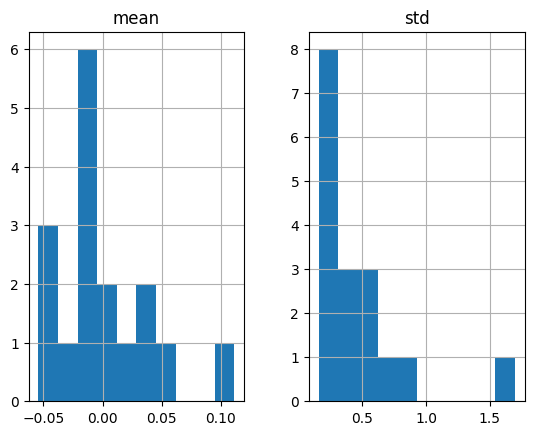

In [56]:
stats_df.hist(bins=10)

In [72]:
from dateutil.relativedelta import relativedelta
from tqdm.notebook import tqdm

data = []
zero_count = 0
for inner_distance in [
    relativedelta(days=0),
    relativedelta(days=1),
    relativedelta(days=2),
    relativedelta(weeks=1),
    relativedelta(months=1),
]:
    print(inner_distance)
    for outer_distance in tqdm(
        [
            relativedelta(days=1),
            relativedelta(days=2),
            relativedelta(days=3),
            relativedelta(weeks=1),
            relativedelta(weeks=2),
            relativedelta(months=1),
            relativedelta(months=2),
            relativedelta(months=3),
            relativedelta(months=6),
            relativedelta(years=1),
        ]
    ):
        for topic in count_df["topic"].unique():
            df = count_df[count_df["topic"] == topic]
            protest_counts = df[
                (df["type"] == "protest")
                & (df.date.dt.year >= 2014)
                & (df.date.dt.year <= 2021)
            ]
            for a in protest_counts.to_dict(orient="records"):
                before_start = a["date"] - outer_distance
                before_end = a["date"] - inner_distance
                previous_count = topic_count_df[
                    (topic_count_df.date >= before_start)
                    & (topic_count_df.date <= before_end)
                    & (topic_count_df.topic == topic)
                ]["count"].sum()
                after_start = a["date"] + inner_distance
                after_end = a["date"] + outer_distance
                next_count = topic_count_df[
                    (topic_count_df.date >= after_start)
                    & (topic_count_df.date <= after_end)
                    & (topic_count_df.topic == topic)
                ]["count"].sum()
                if previous_count == 0 or next_count == 0:
                    zero_count += 1
                    continue
                data.append(
                    {
                        "inner_distance": str(inner_distance),
                        "outer_distance": str(outer_distance),
                        "topic": topic,
                        "date": a["date"],
                        "protest_count": a["count"],
                        "previous_month_count": previous_count,
                        "next_month_count": next_count,
                        "change": next_count / previous_count,
                    }
                )
        df = pd.DataFrame(data)
        df.to_csv(
            project_root / "data" / "protest" / "experiment_association.csv",
            index=False,
        )

relativedelta()


  0%|          | 0/10 [00:00<?, ?it/s]

relativedelta(days=+1)


  0%|          | 0/10 [00:00<?, ?it/s]

relativedelta(days=+2)


  0%|          | 0/10 [00:00<?, ?it/s]

relativedelta(days=+7)


  0%|          | 0/10 [00:00<?, ?it/s]

relativedelta(months=+1)


  0%|          | 0/10 [00:00<?, ?it/s]

In [73]:
for inner_distance in [
    relativedelta(days=0),
    relativedelta(days=1),
    relativedelta(days=2),
    relativedelta(weeks=1),
    relativedelta(months=1),
]:
    print(inner_distance)
    for outer_distance in tqdm(
        [
            relativedelta(days=1),
            relativedelta(days=2),
            relativedelta(days=3),
            relativedelta(weeks=1),
            relativedelta(weeks=2),
            relativedelta(months=1),
            relativedelta(months=2),
            relativedelta(months=3),
            relativedelta(months=6),
            relativedelta(years=1),
        ]
    ):
        df_part = df[
            (df["inner_distance"] == str(inner_distance))
            & (df["outer_distance"] == str(outer_distance))
        ].copy()
        df_part["log_change"] = df_part["change"].apply(lambda x: np.log2(x))
        print(str(inner_distance), outer_distance)
        print(df_part["log_change"].mean(), df_part["log_change"].std())
        print()

relativedelta()


  0%|          | 0/10 [00:00<?, ?it/s]

relativedelta() relativedelta(days=+1)
-0.002507416550408281 0.6116820996948545

relativedelta() relativedelta(days=+2)
-0.00639826804665819 0.6502097049477179

relativedelta() relativedelta(days=+3)
-0.007549857373866587 0.6370524596324253

relativedelta() relativedelta(days=+7)
-0.007319364539522744 0.5582221960527544

relativedelta() relativedelta(days=+14)
-0.007285635644512419 0.4651773841773041

relativedelta() relativedelta(months=+1)
-0.014466509278070062 0.39625038159986775

relativedelta() relativedelta(months=+2)
-0.01566903976210184 0.3465084542470842

relativedelta() relativedelta(months=+3)
-0.023297343822802376 0.3238299482950278

relativedelta() relativedelta(months=+6)
-0.05427659705073091 0.3257826995469742

relativedelta() relativedelta(years=+1)
-0.10143251505273547 0.3608850072122366

relativedelta(days=+1)


  0%|          | 0/10 [00:00<?, ?it/s]

relativedelta(days=+1) relativedelta(days=+1)
-0.0033331432371236235 0.963235161056638

relativedelta(days=+1) relativedelta(days=+2)
-0.0064561224680894065 0.8849516384945735

relativedelta(days=+1) relativedelta(days=+3)
-0.010999418036984055 0.8124333367359181

relativedelta(days=+1) relativedelta(days=+7)
-0.007905640452579975 0.640525912972224

relativedelta(days=+1) relativedelta(days=+14)
-0.007968809200074428 0.5052176671444776

relativedelta(days=+1) relativedelta(months=+1)
-0.014841210809233675 0.4132396283362914

relativedelta(days=+1) relativedelta(months=+2)
-0.01580288624623753 0.35364918759933023

relativedelta(days=+1) relativedelta(months=+3)
-0.023521262614665632 0.3280361812046496

relativedelta(days=+1) relativedelta(months=+6)
-0.05455345524553471 0.3278698194733125

relativedelta(days=+1) relativedelta(years=+1)
-0.10168461952849706 0.3620345053576745

relativedelta(days=+2)


...

relativedelta(days=+2) relativedelta(days=+1)
nan nan

relativedelta(days=+2) relativedelta(days=+2)
-0.008450872103124627 0.9812708952781068

relativedelta(days=+2) relativedelta(days=+3)
-0.012900975009726113 0.89855601816376

relativedelta(days=+2) relativedelta(days=+7)
-0.009830580915634346 0.687463620652128

relativedelta(days=+2) relativedelta(days=+14)
-0.007987280988732854 0.5263425680473331

relativedelta(days=+2) relativedelta(months=+1)
-0.015374554717268745 0.42303428363194334

relativedelta(days=+2) relativedelta(months=+2)
-0.015904863392352704 0.3584308206488199

relativedelta(days=+2) relativedelta(months=+3)
-0.023648509785165785 0.3311540262189018

relativedelta(days=+2) relativedelta(months=+6)
-0.05479032950107498 0.32974470817774343

relativedelta(days=+2) relativedelta(years=+1)
-0.10191848670499218 0.36315819703894053

relativedelta(days=+7)


  0%|          | 0/10 [00:00<?, ?it/s]

relativedelta(days=+7) relativedelta(days=+1)
nan nan

relativedelta(days=+7) relativedelta(days=+2)
nan nan

relativedelta(days=+7) relativedelta(days=+3)
nan nan

relativedelta(days=+7) relativedelta(days=+7)
0.0031007839404368995 0.9804956317244937

relativedelta(days=+7) relativedelta(days=+14)
0.0013742777416019417 0.6439575976193823

relativedelta(days=+7) relativedelta(months=+1)
-0.015771848878524754 0.4734493764404082

relativedelta(days=+7) relativedelta(months=+2)
-0.015851892971499734 0.38007033015258274

relativedelta(days=+7) relativedelta(months=+3)
-0.024125133185931857 0.34492071067588403

relativedelta(days=+7) relativedelta(months=+6)
-0.05586961787489478 0.3380700709955652

relativedelta(days=+7) relativedelta(years=+1)
-0.1030354485686469 0.36833719620253796

relativedelta(months=+1)


  0%|          | 0/10 [00:00<?, ?it/s]

relativedelta(months=+1) relativedelta(days=+1)
nan nan

relativedelta(months=+1) relativedelta(days=+2)
nan nan

relativedelta(months=+1) relativedelta(days=+3)
nan nan

relativedelta(months=+1) relativedelta(days=+7)
nan nan

relativedelta(months=+1) relativedelta(days=+14)
nan nan

relativedelta(months=+1) relativedelta(months=+1)
-0.02728827833052959 1.0227444571433932

relativedelta(months=+1) relativedelta(months=+2)
-0.019100778095093283 0.47557234929342057

relativedelta(months=+1) relativedelta(months=+3)
-0.028286170928309918 0.39577347630128645

relativedelta(months=+1) relativedelta(months=+6)
-0.06205141756942355 0.37082062332668864

relativedelta(months=+1) relativedelta(years=+1)
-0.10876327816720738 0.3922349011849007

